In [1]:
import torch
import numpy as np

In [2]:
CHANNELS = ['DA', '5HT', 'NE', 'pH']

for f in ['volta_train/lopo_volta.pt', 'act_train/lopo_act.pt']:
    r = torch.load(f)
    t = r['tgts_nM'].numpy(); p = r['preds_nM'].numpy()
    print(f"\n=== {f} ({r['tag']}) ===")
    print(f"  rows: {len(t)}   probes: {len(np.unique(r['probe_of_row']))}")
    for j, c in enumerate(CHANNELS):
        print(f"  {c:4}  TGT min {t[:,j].min():8.3f} max {t[:,j].max():8.3f} mean {t[:,j].mean():8.3f}"
              f"   |  PRED min {p[:,j].min():8.3f} max {p[:,j].max():8.3f} mean {p[:,j].mean():8.3f}")
    # negativity check: softplus preds are >=0, but targets can dip <0 from train-fit shift
    print(f"  targets <0: {(t<0).sum()}   preds <0: {(p<0).sum()}  (preds should be exactly 0)")

/tmp/ipykernel_1598573/4034537845.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  r = torch.load(f)



=== volta_train/lopo_volta.pt (volta) ===
  rows: 127050   probes: 7
  DA    TGT min   -0.000 max 2520.000 mean  462.645   |  PRED min   -0.000 max 5236.108 mean  623.626
  5HT   TGT min   -0.000 max 2520.000 mean  465.620   |  PRED min    0.000 max 3218.644 mean  409.992
  NE    TGT min    0.000 max 2490.000 mean  461.653   |  PRED min    0.000 max 3285.685 mean  433.333
  pH    TGT min    7.000 max    7.800 mean    7.400   |  PRED min    7.010 max    7.693 mean    7.394
  targets <0: 34650   preds <0: 738  (preds should be exactly 0)

=== act_train/lopo_act.pt (act) ===
  rows: 127050   probes: 7
  DA    TGT min   -0.000 max 2520.000 mean  462.645   |  PRED min   -0.000 max 3029.103 mean  459.034
  5HT   TGT min   -0.000 max 2520.000 mean  465.620   |  PRED min   -0.000 max 3317.074 mean  477.241
  NE    TGT min    0.000 max 2490.000 mean  461.653   |  PRED min    0.000 max 3636.276 mean  428.998
  pH    TGT min    7.000 max    7.800 mean    7.400   |  PRED min    7.003 max    8.071

In [3]:
from scipy.stats import pearsonr

CHANNELS = ['DA', '5HT', 'NE', 'pH']

def r2_var(y, yh):                              # variance-explained (sklearn r2_score)
    ss_res = ((y - yh) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

def r2_corr(y, yh):                             # squared Pearson — paper's "R2 of linear fit"
    if np.std(y) < 1e-12 or np.std(yh) < 1e-12:
        return np.nan
    return pearsonr(y, yh)[0] ** 2

def report(path):
    r = torch.load(path)
    t, p, probe = r['tgts_nM'].numpy(), r['preds_nM'].numpy(), r['probe_of_row']
    probes = np.unique(probe)
    tag = r['tag']

    print(f"\n{'='*68}\n[{tag}]  (DA/5HT/NE in nM, pH in pH units)\n{'='*68}")

    # --- pooled across all rows ---
    print(f"{'':6}{'POOLED':>20}")
    print(f"  {'analyte':8}{'R2_var':>10}{'R2_corr':>10}")
    pooled = {}
    for j, c in enumerate(CHANNELS):
        rv, rc = r2_var(t[:, j], p[:, j]), r2_corr(t[:, j], p[:, j])
        pooled[c] = (rv, rc)
        print(f"  {c:8}{rv:10.3f}{rc:10.3f}")

    # --- per-probe, then average (the cross-probe generalization number) ---
    print(f"\n  per-probe mean ± std (averaged over {len(probes)} held-out probes)")
    print(f"  {'analyte':8}{'R2_var':>16}{'R2_corr':>16}")
    perprobe = {}
    for j, c in enumerate(CHANNELS):
        rv = [r2_var(t[probe == pr, j], p[probe == pr, j]) for pr in probes]
        rc = [r2_corr(t[probe == pr, j], p[probe == pr, j]) for pr in probes]
        rv, rc = np.array(rv), np.array(rc)
        perprobe[c] = (rv, rc)
        print(f"  {c:8}  {np.nanmean(rv):6.3f} ± {np.nanstd(rv):5.3f}   "
              f"{np.nanmean(rc):6.3f} ± {np.nanstd(rc):5.3f}")
    return {'tag': tag, 'probes': probes, 'pooled': pooled, 'perprobe': perprobe}

res_v = report('volta_train/lopo_volta.pt')
res_a = report('act_train/lopo_act.pt')

# --- paired comparison: per-probe R2 difference, same probe order ---
print(f"\n{'='*68}\nPAIRED  (act − volta) per-probe R2, + = activations better\n{'='*68}")
assert np.array_equal(res_v['probes'], res_a['probes']), "probe order mismatch — not paired!"
for metric, idx in [('R2_var', 0), ('R2_corr', 1)]:
    print(f"\n  {metric}:")
    print(f"  {'analyte':8}{'mean Δ':>10}{'wins(act/7)':>14}")
    for c in CHANNELS:
        dv = res_a['perprobe'][c][idx] - res_v['perprobe'][c][idx]
        wins = int(np.nansum(dv > 0))
        print(f"  {c:8}{np.nanmean(dv):10.3f}{f'{wins}/{len(dv)}':>14}")

/tmp/ipykernel_1598573/3320669525.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  r = torch.load(path)



[volta]  (DA/5HT/NE in nM, pH in pH units)
                    POOLED
  analyte     R2_var   R2_corr
  DA          -0.534     0.139
  5HT          0.154     0.288
  NE          -0.115     0.130
  pH          -1.819     0.009

  per-probe mean ± std (averaged over 7 held-out probes)
  analyte           R2_var         R2_corr
  DA        -0.542 ± 1.080    0.230 ± 0.111
  5HT        0.153 ± 0.306    0.367 ± 0.146
  NE        -0.115 ± 0.415    0.195 ± 0.203
  pH        -1.819 ± 1.577    0.035 ± 0.040

[act]  (DA/5HT/NE in nM, pH in pH units)
                    POOLED
  analyte     R2_var   R2_corr
  DA           0.008     0.170
  5HT          0.430     0.474
  NE          -0.138     0.098
  pH          -0.126     0.087

  per-probe mean ± std (averaged over 7 held-out probes)
  analyte           R2_var         R2_corr
  DA         0.006 ± 0.463    0.259 ± 0.149
  5HT        0.430 ± 0.180    0.511 ± 0.107
  NE        -0.138 ± 0.459    0.174 ± 0.149
  pH        -0.126 ± 0.383    0.141 ± 0.

/tmp/ipykernel_1598573/1455888313.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  r = torch.load(path)


saved crosspred_volta.png
saved crosspred_act.png


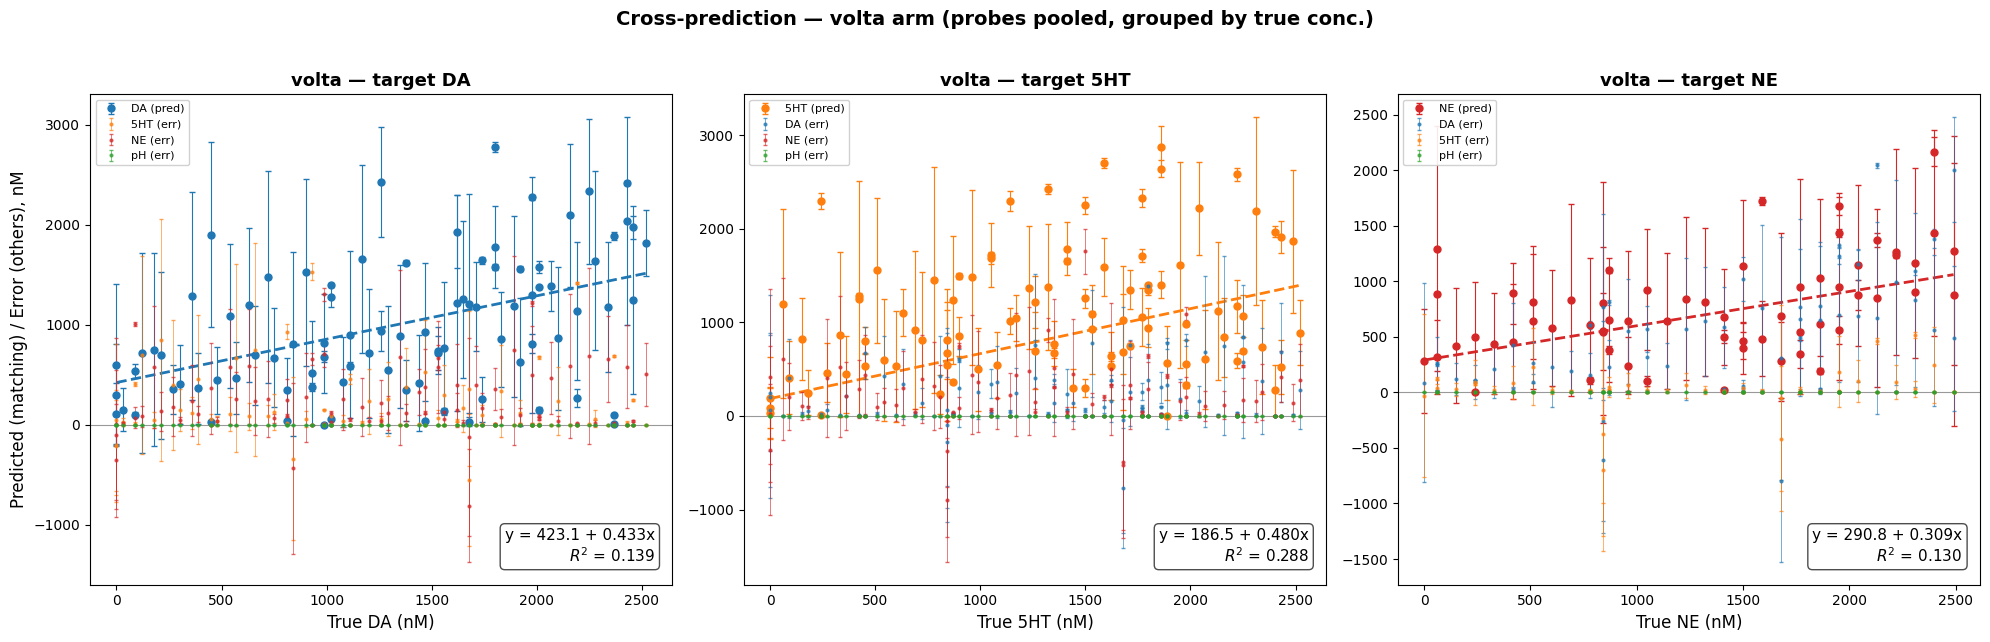

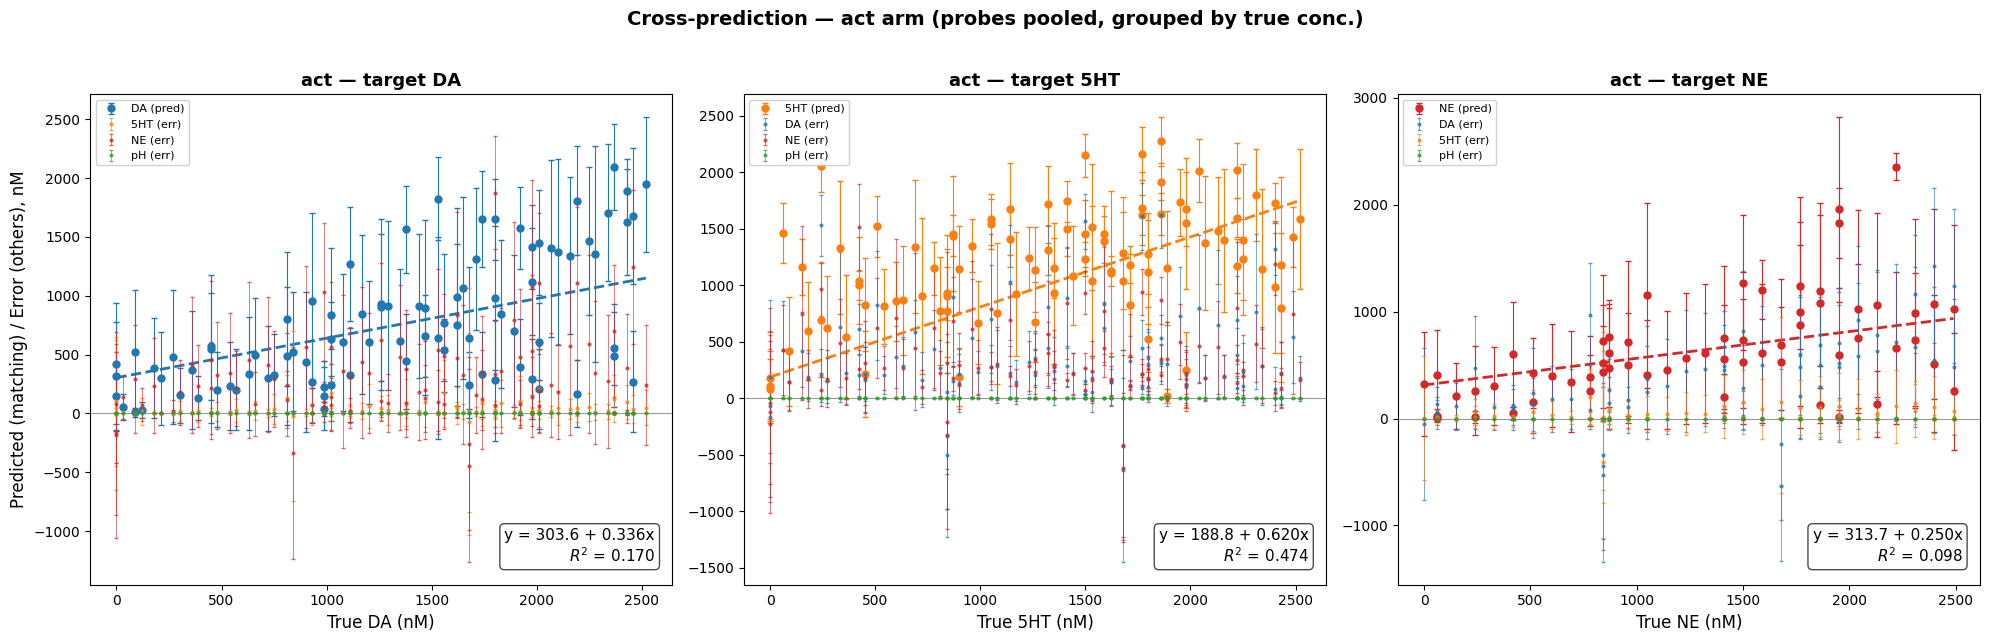

In [4]:
import matplotlib.pyplot as plt

COLS   = ['DA', '5HT', 'NE', 'pH']
COLOR  = {'DA':'#1f77b4', '5HT':'#ff7f0e', 'NE':'#d62728', 'pH':'#2ca02c'}
TARGETS = ['DA', '5HT', 'NE']
ARMS = [('volta', 'volta_train/lopo_volta.pt'),
        ('act',   'act_train/lopo_act.pt')]

def grouped(true_vec, val_vec):
    """mean ± std of val_vec, grouped by unique value of true_vec."""
    u = np.unique(true_vec)
    m = np.array([val_vec[true_vec == c].mean() for c in u])
    s = np.array([val_vec[true_vec == c].std()  for c in u])
    return u, m, s

for tag, path in ARMS:
    r = torch.load(path)
    t, p = r['tgts_nM'].numpy(), r['preds_nM'].numpy()

    fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
    for ax, tgt in zip(axes, TARGETS):
        jt = COLS.index(tgt)
        xtrue = t[:, jt]

        # matching analyte: predicted value (the diagonal series)
        u, m, s = grouped(xtrue, p[:, jt])
        ax.errorbar(u, m, yerr=s, fmt='o', ms=5, color=COLOR[tgt],
                    capsize=2, lw=0.8, label=f'{tgt} (pred)')
        slope, intc = np.polyfit(xtrue, p[:, jt], 1)
        r2 = pearsonr(xtrue, p[:, jt])[0] ** 2
        xs = np.array([xtrue.min(), xtrue.max()])
        ax.plot(xs, slope * xs + intc, '--', color=COLOR[tgt], lw=2)
        ax.text(0.97, 0.04, f'y = {intc:.1f} + {slope:.3f}x\n$R^2$ = {r2:.3f}',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=11,
                bbox=dict(boxstyle='round', fc='white', ec='0.3'))

        # other analytes: prediction ERROR (pred - true), should stay flat at 0
        for other in [c for c in COLS if c != tgt]:
            jo = COLS.index(other)
            err = p[:, jo] - t[:, jo]
            u2, m2, s2 = grouped(xtrue, err)
            ax.errorbar(u2, m2, yerr=s2, fmt='.', ms=4, color=COLOR[other],
                        alpha=0.7, capsize=1.5, lw=0.6, label=f'{other} (err)')

        ax.axhline(0, color='0.6', lw=0.8, zorder=0)
        ax.set_xlabel(f'True {tgt} (nM)', fontsize=12)
        ax.set_title(f'{tag} — target {tgt}', fontsize=13, fontweight='bold')
        ax.legend(fontsize=8, loc='upper left', framealpha=0.9)
    axes[0].set_ylabel('Predicted (matching) / Error (others), nM', fontsize=12)

    fig.suptitle(f'Cross-prediction — {tag} arm (probes pooled, grouped by true conc.)',
                 fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out = f'crosspred_{tag}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print('saved', out)

In [5]:
r = torch.load('volta_train/lopo_volta.pt'); t = r['tgts_nM'].numpy()
print(np.corrcoef(t[:, :3].T))   # rows/cols = DA, 5HT, NE

[[ 1.         -0.11088166 -0.10804771]
 [-0.11088166  1.         -0.11019129]
 [-0.10804771 -0.11019129  1.        ]]


/tmp/ipykernel_1598573/78786004.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  r = torch.load('volta_train/lopo_volta.pt'); t = r['tgts_nM'].numpy()


In [6]:

COLS = ['DA', '5HT', 'NE']
for tag, path in [('volta','volta_train/lopo_volta.pt'), ('act','act_train/lopo_act.pt')]:
    r = torch.load(path, weights_only=False)
    t, p = r['tgts_nM'].numpy(), r['preds_nM'].numpy()
    print(f"\n[{tag}]  predicted = intercept + slope·true   (ideal: slope=1, intercept=0)")
    for j, c in enumerate(COLS):
        slope, intc = np.polyfit(t[:, j], p[:, j], 1)
        # decompose mean error into bias vs scale contribution
        print(f"  {c:4}  slope {slope:5.3f}   intercept {intc:7.1f}   "
              f"pred_mean {p[:,j].mean():6.1f}  true_mean {t[:,j].mean():6.1f}")


[volta]  predicted = intercept + slope·true   (ideal: slope=1, intercept=0)
  DA    slope 0.433   intercept   423.1   pred_mean  623.6  true_mean  462.6
  5HT   slope 0.480   intercept   186.5   pred_mean  410.0  true_mean  465.6
  NE    slope 0.309   intercept   290.8   pred_mean  433.3  true_mean  461.7

[act]  predicted = intercept + slope·true   (ideal: slope=1, intercept=0)
  DA    slope 0.336   intercept   303.6   pred_mean  459.0  true_mean  462.6
  5HT   slope 0.620   intercept   188.8   pred_mean  477.2  true_mean  465.6
  NE    slope 0.250   intercept   313.7   pred_mean  429.0  true_mean  461.7


saved r2corr_per_probe.png

probe                        DA_v    DA_a   5HT_v   5HT_a    NE_v    NE_a
ALC1_INM001_01bW04R01M       0.29    0.22    0.15    0.51    0.00    0.03
ALC2_INM001_02bW02R01M       0.16    0.07    0.24    0.26    0.04    0.03
ALC3_INM001_03bW02R01M       0.39    0.43    0.65    0.56    0.39    0.18
ALC3_INM001_03bW06R02M       0.28    0.42    0.35    0.59    0.08    0.26
ALC4_INM001_04bW02R01M       0.23    0.39    0.42    0.59    0.59    0.46
ALC4_INM001_04bW06R02M       0.25    0.25    0.42    0.57    0.06    0.24
ALC4_INM001_04bW08R03M       0.01    0.04    0.35    0.50    0.20    0.02


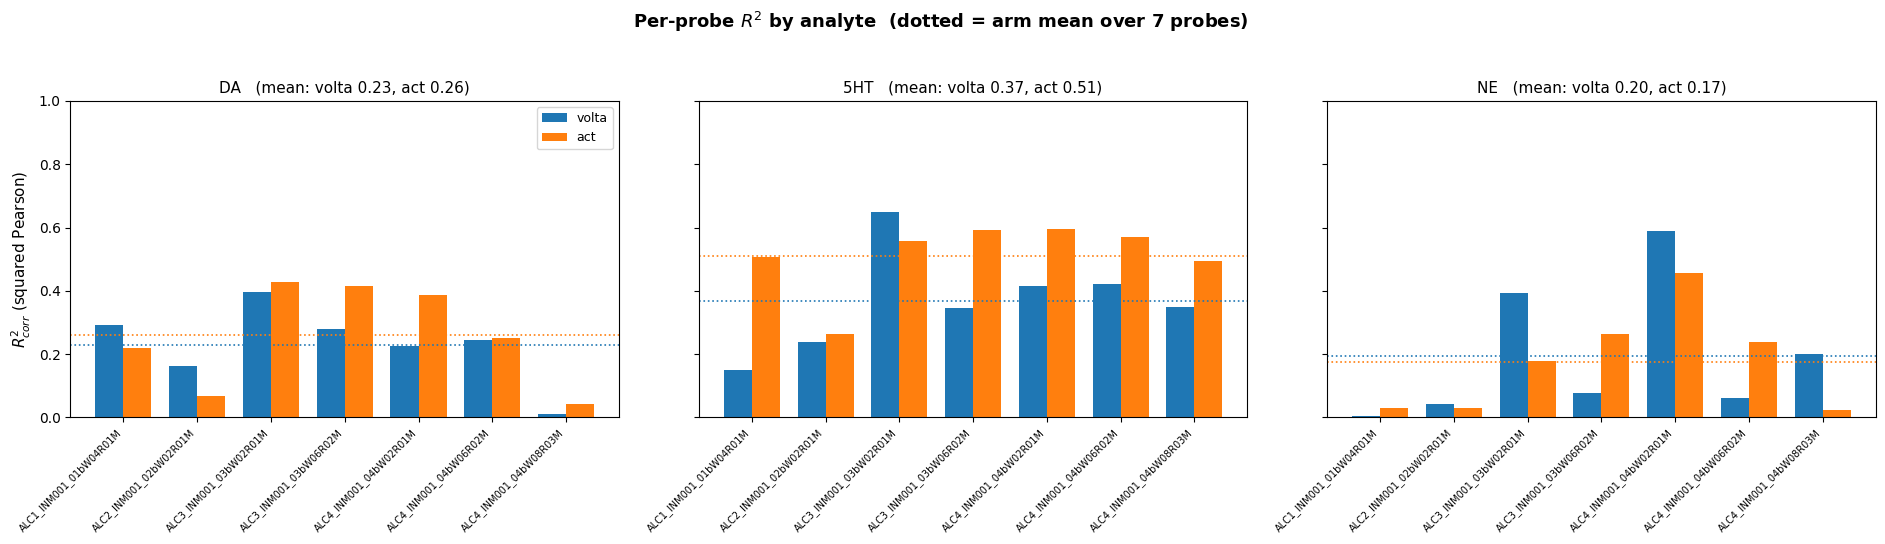

In [13]:
COLS = ['DA', '5HT', 'NE', 'pH']
MONO = ['DA', '5HT', 'NE']
ARMS = [('volta', 'volta_train/lopo_volta.pt'),
        ('act',   'act_train/lopo_act.pt')]

def r2_corr(y, yh):
    if np.std(y) < 1e-9 or np.std(yh) < 1e-9: return np.nan
    return pearsonr(y, yh)[0] ** 2

data = {}
for tag, path in ARMS:
    r = torch.load(path, weights_only=False)
    t, p, probe = r['tgts_nM'].numpy(), r['preds_nM'].numpy(), r['probe_of_row']
    probes = np.unique(probe)
    data[tag] = {c: np.array([r2_corr(t[probe==pr, COLS.index(c)],
                                      p[probe==pr, COLS.index(c)]) for pr in probes])
                 for c in MONO}
data['_probes'] = probes

probes = data['_probes']
short = [pr.split('__')[-1] for pr in probes]
x = np.arange(len(probes)); W = 0.38

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), sharey=True)
for col, c in enumerate(MONO):
    ax = axes[col]
    v, a = data['volta'][c], data['act'][c]
    ax.bar(x - W/2, v, W, label='volta', color='#1f77b4')
    ax.bar(x + W/2, a, W, label='act',   color='#ff7f0e')
    ax.axhline(np.nanmean(v), color='#1f77b4', ls=':', lw=1.2)
    ax.axhline(np.nanmean(a), color='#ff7f0e', ls=':', lw=1.2)
    ax.set_title(f'{c}   (mean: volta {np.nanmean(v):.2f}, act {np.nanmean(a):.2f})', fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_xticks(x); ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
    if col == 0:
        ax.set_ylabel(r'$R^2_{corr}$ (squared Pearson)', fontsize=11)
        ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Per-probe $R^2$ by analyte  (dotted = arm mean over 7 probes)',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('r2corr_per_probe.png', dpi=150, bbox_inches='tight')
print('saved r2corr_per_probe.png')

print(f"\n{'probe':24} " + "".join(f"{c+'_v':>8}{c+'_a':>8}" for c in MONO))
for i, pr in enumerate(short):
    print(f"{pr:24} " + "".join(f"{data['volta'][c][i]:8.2f}{data['act'][c][i]:8.2f}" for c in MONO))

saved alc1_mlp_truepred.png

                   MLP-volta             MLP-act
analyte      slope       R2c     slope       R2c
DA           0.999     0.998     0.752     0.738
5HT          0.995     0.999     0.706     0.679
NE           1.001     0.999     0.597     0.494


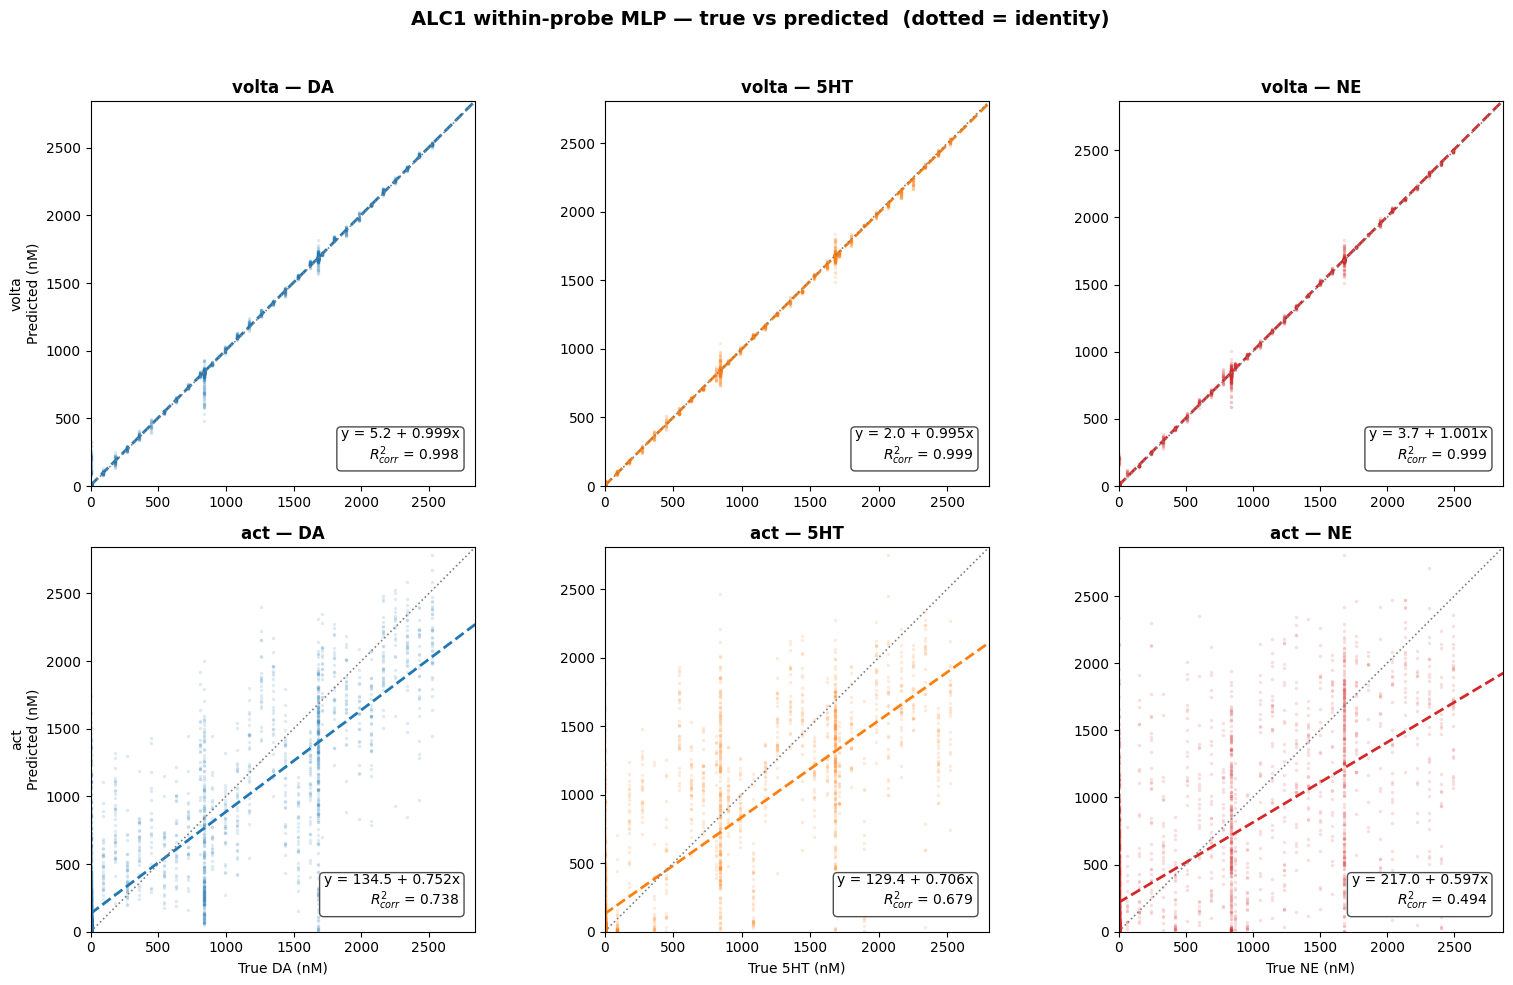

In [ ]:


COLS  = ['DA', '5HT', 'NE', 'pH']
MONO  = ['DA', '5HT', 'NE']
PROBE_SHORT = 'ALC1_INM001_01bW04R01M'
ARMS = [('volta', f'within_probe/{PROBE_SHORT}/volta/results.pt'),
        ('act',   f'within_probe/{PROBE_SHORT}/act/results.pt')]
COLOR = {'DA': '#1f77b4', '5HT': '#ff7f0e', 'NE': '#d62728'}

data = {tag: torch.load(p, weights_only=False) for tag, p in ARMS}

# shared per-analyte limits across both arms
lims = {}
for c in MONO:
    j = COLS.index(c)
    vals = np.concatenate([np.r_[data[t]['tgts_nM'].numpy()[:, j],
                                 data[t]['preds_nM'].numpy()[:, j]] for t, _ in ARMS])
    lims[c] = (min(0, vals.min()) * 1.02, vals.max() * 1.02)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for r, (tag, _) in enumerate(ARMS):
    t_arr = data[tag]['tgts_nM'].numpy()
    p_arr = data[tag]['preds_nM'].numpy()
    for col, c in enumerate(MONO):
        j = COLS.index(c)
        ax = axes[r, col]
        x, y = t_arr[:, j], p_arr[:, j]

        ax.scatter(x, y, s=6, alpha=0.15, color=COLOR[c], linewidths=0)
        slope, intc = np.polyfit(x, y, 1)
        r2c = pearsonr(x, y)[0] ** 2
        lo, hi = lims[c]; xs = np.array([lo, hi])
        ax.plot(xs, slope * xs + intc, '--', color=COLOR[c], lw=2)
        ax.plot(xs, xs, ':', color='0.5', lw=1.2)              # identity
        ax.text(0.96, 0.05, f'y = {intc:.1f} + {slope:.3f}x\n$R^2_{{corr}}$ = {r2c:.3f}',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', ec='0.3'))
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal', 'box')
        ax.set_title(f'{tag} — {c}', fontsize=12, fontweight='bold')
        if r == 1: ax.set_xlabel(f'True {c} (nM)')
        if col == 0: ax.set_ylabel(f'{tag}\nPredicted (nM)')

fig.suptitle(f'ALC1 within-probe MLP — true vs predicted  (dotted = identity)',
             fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('alc1_mlp_truepred.png', dpi=150, bbox_inches='tight')
print('saved alc1_mlp_truepred.png')

# the comparison table you actually read conclusions from
print(f"\n{'':8}{'MLP-volta':>20}{'MLP-act':>20}")
print(f"{'analyte':8}{'slope':>10}{'R2c':>10}{'slope':>10}{'R2c':>10}")
for c in MONO:
    row = f"{c:8}"
    for tag, _ in ARMS:
        m = data[tag]['metrics'][c]
        row += f"{m['slope']:10.3f}{m['r2_corr']:10.3f}"
    print(row)

saved alc1_mlp_truepred.png

                   MLP-volta             MLP-act
analyte      slope       R2c     slope       R2c
DA           0.922     0.836     0.849     0.693
5HT          0.791     0.839     0.562     0.750
NE           0.702     0.705     0.579     0.502


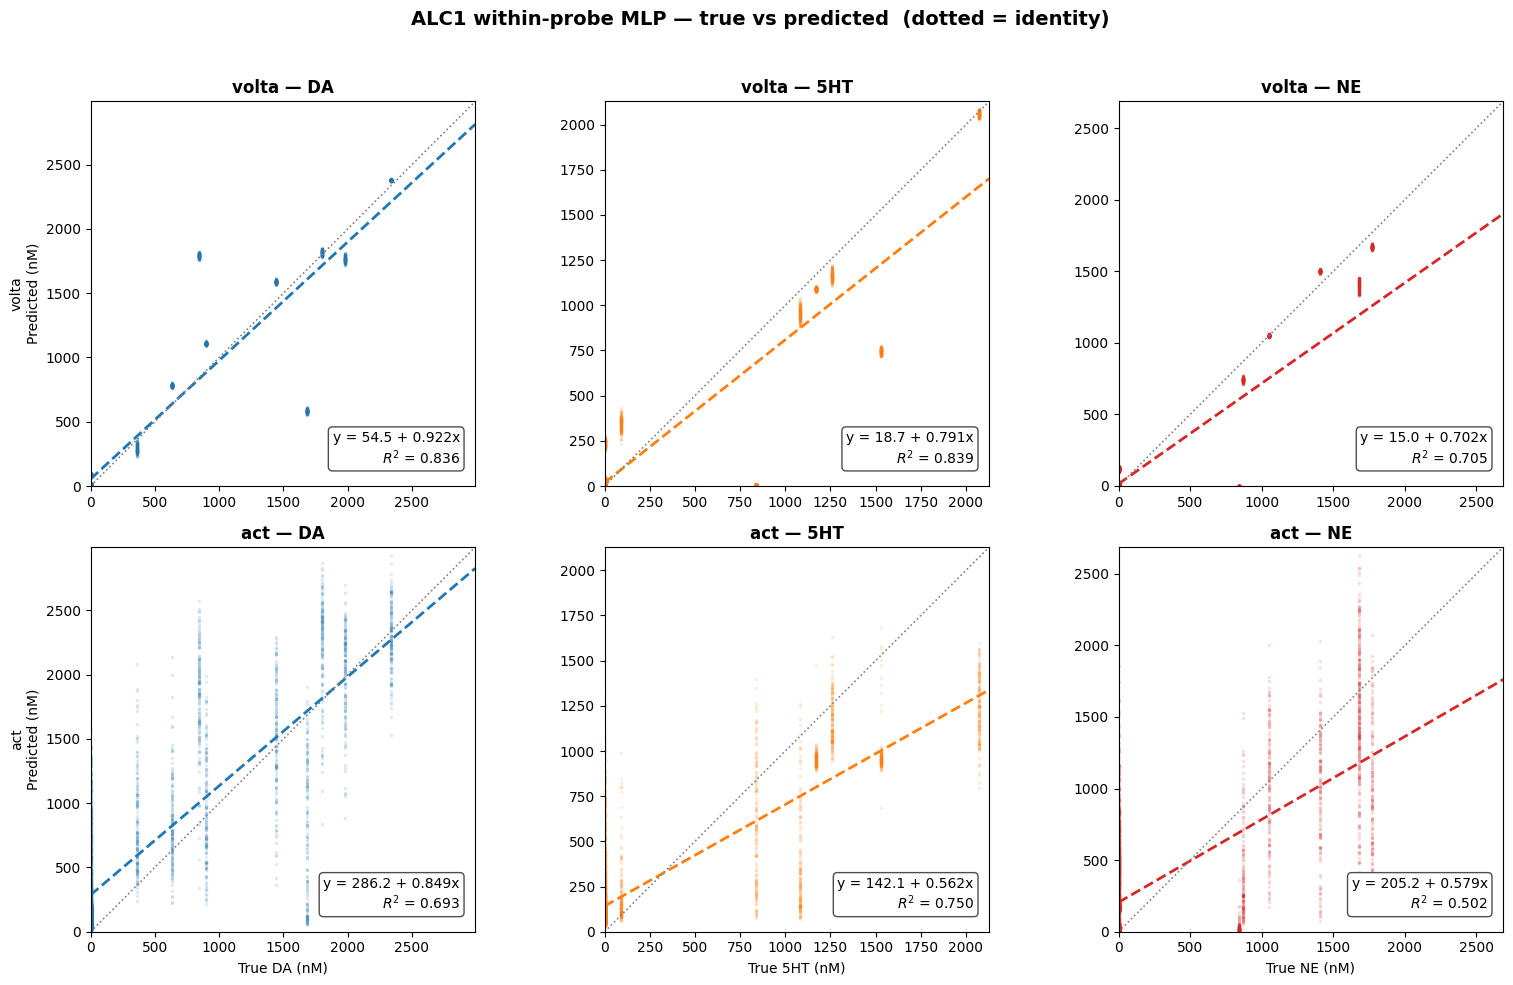

In [12]:


COLS  = ['DA', '5HT', 'NE', 'pH']
MONO  = ['DA', '5HT', 'NE']
PROBE_SHORT = 'ALC1_INM001_01bW04R01M'
ARMS = [('volta', f'within_probe_blocked/{PROBE_SHORT}/volta/results.pt'),
        ('act',   f'within_probe_blocked/{PROBE_SHORT}/act/results.pt')]
COLOR = {'DA': '#1f77b4', '5HT': '#ff7f0e', 'NE': '#d62728'}

data = {tag: torch.load(p, weights_only=False) for tag, p in ARMS}

# shared per-analyte limits across both arms
lims = {}
for c in MONO:
    j = COLS.index(c)
    vals = np.concatenate([np.r_[data[t]['tgts_nM'].numpy()[:, j],
                                 data[t]['preds_nM'].numpy()[:, j]] for t, _ in ARMS])
    lims[c] = (min(0, vals.min()) * 1.02, vals.max() * 1.02)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for r, (tag, _) in enumerate(ARMS):
    t_arr = data[tag]['tgts_nM'].numpy()
    p_arr = data[tag]['preds_nM'].numpy()
    for col, c in enumerate(MONO):
        j = COLS.index(c)
        ax = axes[r, col]
        x, y = t_arr[:, j], p_arr[:, j]

        ax.scatter(x, y, s=6, alpha=0.15, color=COLOR[c], linewidths=0)
        slope, intc = np.polyfit(x, y, 1)
        r2c = pearsonr(x, y)[0] ** 2
        lo, hi = lims[c]; xs = np.array([lo, hi])
        ax.plot(xs, slope * xs + intc, '--', color=COLOR[c], lw=2)
        ax.plot(xs, xs, ':', color='0.5', lw=1.2)              # identity
        ax.text(0.96, 0.05, f'y = {intc:.1f} + {slope:.3f}x\n$R^2$ = {r2c:.3f}',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', ec='0.3'))
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal', 'box')
        ax.set_title(f'{tag} — {c}', fontsize=12, fontweight='bold')
        if r == 1: ax.set_xlabel(f'True {c} (nM)')
        if col == 0: ax.set_ylabel(f'{tag}\nPredicted (nM)')

fig.suptitle(f'ALC1 within-probe MLP — true vs predicted  (dotted = identity)',
             fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('alc1_mlp_truepred.png', dpi=150, bbox_inches='tight')
print('saved alc1_mlp_truepred.png')

# the comparison table you actually read conclusions from
print(f"\n{'':8}{'MLP-volta':>20}{'MLP-act':>20}")
print(f"{'analyte':8}{'slope':>10}{'R2c':>10}{'slope':>10}{'R2c':>10}")
for c in MONO:
    row = f"{c:8}"
    for tag, _ in ARMS:
        m = data[tag]['metrics'][c]
        row += f"{m['slope']:10.3f}{m['r2_corr']:10.3f}"
    print(row)

In [9]:
import numpy as np, torch
from pathlib import Path
from utils import get_activation_label_pair

FOLDER = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF"
PROBE_SHORT = 'ALC1_INM001_01bW04R01M'
# load ALC1's raw volta + labels the same way the loader groups them
# (reuse your get_activation_label_pair on just this probe's folder, or load directly)
r = torch.load(f'within_probe/{PROBE_SHORT}/volta/results.pt', weights_only=False)
# we need the FULL probe arrays, not just test — reload from disk:
acts, lbls, probes = get_activation_label_pair(FOLDER, collapsed=False, volta=True, model_dim='3d')
m = probes == [p for p in np.unique(probes) if PROBE_SHORT in p][0]
X = acts[m].reshape(m.sum(), -1)        # (N, 1000)
Y = lbls[m]                              # (N, 4)

# group rows by their full 4-tuple concentration label
keys = [tuple(np.round(y, 3)) for y in Y]
uniq = {}
for i, k in enumerate(keys): uniq.setdefault(k, []).append(i)
print(f"{len(X)} sweeps, {len(uniq)} unique concentration combos, "
      f"~{len(X)/len(uniq):.0f} sweeps/combo")

# within-combo similarity: how close are sweeps at the SAME concentration?
import random
rng = np.random.default_rng(0)
within, across = [], []
combo_list = [v for v in uniq.values() if len(v) >= 2]
for idxs in random.sample(combo_list, min(50, len(combo_list))):
    a, b = rng.choice(idxs, 2, replace=False)
    within.append(np.corrcoef(X[a], X[b])[0, 1])
for _ in range(50):                      # random cross-combo pairs
    i, j = rng.integers(0, len(X), 2)
    across.append(np.corrcoef(X[i], X[j])[0, 1])
print(f"within-concentration sweep corr:  mean {np.mean(within):.4f}  min {np.min(within):.4f}")
print(f"across-concentration sweep corr:   mean {np.mean(across):.4f}")

Found 28 paths
Getting pairs not collapsed.
Getting raw voltammograms
First activation shape(5250, 1000, 1)
First label shape(5250, 4)
18150 sweeps, 113 unique concentration combos, ~161 sweeps/combo
within-concentration sweep corr:  mean 1.0000  min 0.9997
across-concentration sweep corr:   mean 0.9987


In [10]:
import numpy as np, torch
from pathlib import Path
from utils import get_activation_label_pair

FOLDER = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF"
PROBE_SHORT = 'ALC1_INM001_01bW04R01M'
# load ALC1's raw volta + labels the same way the loader groups them
# (reuse your get_activation_label_pair on just this probe's folder, or load directly)
r = torch.load(f'within_probe/{PROBE_SHORT}/volta/results.pt', weights_only=False)
# we need the FULL probe arrays, not just test — reload from disk:
acts, lbls, probes = get_activation_label_pair(FOLDER, collapsed=False, volta=False, model_dim='3d')
m = probes == [p for p in np.unique(probes) if PROBE_SHORT in p][0]
X = acts[m].reshape(m.sum(), -1)        # (N, 1000)
Y = lbls[m]                              # (N, 4)

# group rows by their full 4-tuple concentration label
keys = [tuple(np.round(y, 3)) for y in Y]
uniq = {}
for i, k in enumerate(keys): uniq.setdefault(k, []).append(i)
print(f"{len(X)} sweeps, {len(uniq)} unique concentration combos, "
      f"~{len(X)/len(uniq):.0f} sweeps/combo")

# within-combo similarity: how close are sweeps at the SAME concentration?
import random
rng = np.random.default_rng(0)
within, across = [], []
combo_list = [v for v in uniq.values() if len(v) >= 2]
for idxs in random.sample(combo_list, min(50, len(combo_list))):
    a, b = rng.choice(idxs, 2, replace=False)
    within.append(np.corrcoef(X[a], X[b])[0, 1])
for _ in range(50):                      # random cross-combo pairs
    i, j = rng.integers(0, len(X), 2)
    across.append(np.corrcoef(X[i], X[j])[0, 1])
print(f"within-concentration sweep corr:  mean {np.mean(within):.4f}  min {np.min(within):.4f}")
print(f"across-concentration sweep corr:   mean {np.mean(across):.4f}")

Found 28 paths
Getting pairs not collapsed.
First activation shape(5250, 1000, 10)
First label shape(5250, 4)
18150 sweeps, 113 unique concentration combos, ~161 sweeps/combo
within-concentration sweep corr:  mean 0.9987  min 0.9877
across-concentration sweep corr:   mean 0.9929
